# **Installing Dependencies**

In [ ]:
!pip install torch_geometric
!pip install rdkit
!pip install scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 43.9 MB/s eta 0:00:00


# **Dataset Preprocessing**

## Importing the dataset

In [ ]:
import pandas as pd

df_original = pd.read_csv('7Q27.normalized.signatures_with_smiles.csv')
df_original = df_original.head(-3)

df_original.head()

,record_seq_num,unix_timestamp_sec,run_id,run_name,device_id,item,cycle,baseline_start_sec,baseline_end_sec,analyte_start_sec,...,1,105,106,24,25,34,36,55,cleaned_item,SMILES
0,0,1.775659e+09,2604081640,2604081640,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0.583413,0.413874,0.331338,0.281003,0.281038,0.308008,0.262813,0.238051,ocimene,CC(C)/C=C/C=C(\C)/C=C
1,1,1.775658e+09,2604081618,2604081618,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0.532110,0.434074,0.334196,0.290782,0.289314,0.313109,0.263302,0.284833,ocimene,CC(C)/C=C/C=C(\C)/C=C
2,2,1.775657e+09,2604081556,2604081556,NOA222-10002-3H5QU_fsp,Ocimene_080426,1,0,9.99,10.323,...,0.494081,0.473268,0.332771,0.285086,0.301563,0.321381,0.255588,0.283442,ocimene,CC(C)/C=C/C=C(\C)/C=C
3,3,1.775654e+09,2604081518,2604081518,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0.449125,0.467397,0.330214,0.301157,0.322543,0.331946,0.270023,0.304884,delta-3-carene,CC1=CCC2C(C1)C2(C)C
4,4,1.775653e+09,2604081459,2604081459,NOA222-10002-3H5QU_fsp,Delta 3 Carene_080426,1,0,9.99,10.323,...,0.417917,0.445122,0.334211,0.330728,0.320887,0.361776,0.276138,0.309890,delta-3-carene,CC1=CCC2C(C1)C2(C)C


## Checking for NaNs in the dataset

In [ ]:
df_original.isna().sum()

,0
record_seq_num,0
unix_timestamp_sec,0
run_id,0
run_name,0
device_id,0
item,0
cycle,0
baseline_start_sec,0
baseline_end_sec,0
analyte_start_sec,0


Getting the useful columns only

In [ ]:
df = df_original[['SMILES', '1',	'105',	'106',	'24',	'25',	'34',	'36',	'55']]

In [ ]:
df = df.groupby('SMILES', as_index=False).mean()

df

,SMILES,1,105,106,24,25,34,36,55
0,CC(=CCCC(C)(C=C)O)C,0.264869,0.358652,0.298692,0.381457,0.415265,0.439276,0.296656,0.327475
1,CC(C)/C=C/C=C(\C)/C=C,0.536535,0.440405,0.332768,0.285624,0.290638,0.314166,0.260568,0.268775
2,CC1=CCC2C(C1)C2(C)C,0.417571,0.452395,0.329835,0.326511,0.325437,0.362921,0.273972,0.301584
3,CC1=CC[C@@H](CC1)C(=C)C,0.399694,0.250238,0.308442,0.258683,0.291169,0.431988,0.439744,0.383053
4,CC1=CC[C@H](CC1)C(=C)C,0.363499,0.247393,0.291516,0.477187,0.290902,0.397553,0.349345,0.343842
5,CC1=C[C@H]2C[C@@H](C1)C2(C)C,0.170420,0.236334,0.248987,0.562170,0.379745,0.429815,0.307966,0.331353


## Converting the SMILES representation to a graph one

### Converting the SMILES to graphs with `from_smiles`

In [ ]:
import torch
from torch_geometric.utils import from_smiles
from torch_geometric.utils import to_networkx

df_graph = []
labels = []
G = []

for i in range(len(df)):
  smiles = df['SMILES'][i]
  data = from_smiles(smiles, with_hydrogen=0)
  data.x = data.x.float()
  data.y = torch.tensor(df.iloc[i, 1:], dtype=torch.float)
  df_graph.append(data)
  G.append(to_networkx(data, to_undirected=True))
  labels.append(df.iloc[i, 1:])

/tmp/ipykernel_7264/2827183306.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(df.iloc[i, 1:], dtype=torch.float)


## Creating the train and test loaders

In [ ]:
# !pip install scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 4.4 MB/s eta 0:00:00


### Second-order iterative stratification

In [ ]:
# import numpy as np
# import pandas as pd
# from skmultilearn.model_selection import IterativeStratification
# from torch_geometric.loader import DataLoader
# import torch

# def create_stratified_splits(df, label_columns, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
#     X = np.arange(len(df)).reshape(-1, 1)
#     y = label_columns

#     holdout_ratio = val_ratio + test_ratio

#     stratifier_1 = IterativeStratification(
#         n_splits=2,
#         order=2,
#         sample_distribution_per_fold=[holdout_ratio, train_ratio]
#     )

#     train_idx, holdout_idx = next(stratifier_1.split(X, y))

#     print(f"   -> Step 1 Complete: {len(train_idx)} Train samples, {len(holdout_idx)} Holdout samples.")

#     relative_test_ratio = test_ratio / holdout_ratio
#     relative_val_ratio = 1.0 - relative_test_ratio

#     stratifier_2 = IterativeStratification(
#         n_splits=2,
#         order=2,
#         sample_distribution_per_fold=[relative_test_ratio, relative_val_ratio]
#     )

#     X_holdout = X[holdout_idx]
#     y_holdout = y[holdout_idx]

#     val_idx_relative, test_idx_relative = next(stratifier_2.split(X_holdout, y_holdout))

#     val_idx = holdout_idx[val_idx_relative]
#     test_idx = holdout_idx[test_idx_relative]

#     print(f"   -> Step 2 Complete: {len(val_idx)} Val samples, {len(test_idx)} Test samples.")

#     df_train = df.iloc[train_idx].copy()
#     df_val = df.iloc[val_idx].copy()
#     df_test = df.iloc[test_idx].copy()

#     return df_train, df_val, df_test


# train_data, val_data, test_data = create_stratified_splits(
#     df=df,
#     label_columns=df.iloc[:, 2:].values,
#     train_ratio=0.8,
#     val_ratio=0.1,
#     test_ratio=0.1
# )

# df_graph_train = []
# df_graph_val = []
# df_graph_test = []
# labels_train = []
# labels_val = []
# labels_test = []
# G = []

# for i in range(len(train_data)):
#   smiles = train_data['nonStereoSMILES'].iloc[i]
#   data = from_smiles(smiles, with_hydrogen=0)
#   data.x = data.x.float()
#   data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch.float)
#   df_graph_train.append(data)
#   G.append(to_networkx(data, to_undirected=True))
#   labels_train.append(train_data.iloc[i, 2:])

# for i in range(len(val_data)):
#   smiles = val_data['nonStereoSMILES'].iloc[i]
#   data = from_smiles(smiles, with_hydrogen=0)
#   data.x = data.x.float()
#   data.y = torch.tensor(val_data.iloc[i, 2:], dtype=torch.float)
#   df_graph_val.append(data)
#   G.append(to_networkx(data, to_undirected=True))
#   labels_val.append(val_data.iloc[i, 2:])

# for i in range(len(test_data)):
#   smiles = test_data['nonStereoSMILES'].iloc[i]
#   data = from_smiles(smiles, with_hydrogen=0)
#   data.x = data.x.float()
#   data.y = torch.tensor(test_data.iloc[i, 2:], dtype=torch.float)
#   df_graph_test.append(data)
#   G.append(to_networkx(data, to_undirected=True))
#   labels_test.append(test_data.iloc[i, 2:])

# train_data = df_graph_train
# val_data = df_graph_val
# test_data = df_graph_test

# train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
# val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False) # no shuffle needed for eval
# test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

   -> Step 1 Complete: 3971 Train samples, 1012 Holdout samples.
   -> Step 2 Complete: 502 Val samples, 510 Test samples.


/tmp/ipykernel_6050/439607195.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch.float)
/tmp/ipykernel_6050/439607195.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch.float)
/tmp/ipykernel_6050/439607195.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data.y = torch.tensor(train_data.iloc[i, 2:], dtype=torch

### Splits (not using second-order iterative stratification)

In [ ]:
from torch_geometric.loader import DataLoader
import torch

# splitting the dataset into train and test sets
total_size = len(df_graph)
train_size = int(total_size * 0.8)  # 80% for training
val_size   = int(total_size * 0.2)  # 10% for validation
test_size  = total_size - train_size - val_size # 10% for test

# perform the split
train_data = df_graph[:train_size]
val_data   = df_graph[train_size : train_size + val_size]
test_data  = df_graph[train_size + val_size :]

# create loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False) # no shuffle needed for eval
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

len(train_data), len(val_data), len(test_data)

(4, 1, 1)

# **GNN Implementation**

## Model Creation

### GCN Model

#### Global mean pool

##### 2 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_mean_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         # self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         # x = F.relu(x)
#         # x = self.conv3(x, edge_index)

#         x = global_mean_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 3 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_mean_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)

#         x = global_mean_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 4 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_mean_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 256) # changed this layer to fit the fourth layer
#         self.conv4 = GCNConv(256, 128) # new layer

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.conv4(x, edge_index)

#         x = global_mean_pool(x, batch)

#         x = self.lin(x)

#         return x

#### Global max pool

##### 2 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_max_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         # self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         # x = F.relu(x)
#         # x = self.conv3(x, edge_index)

#         x = global_max_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 3 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_max_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 128)

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)

#         x = global_max_pool(x, batch)

#         x = self.lin(x)

#         return x

##### 4 GCN Layers

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_max_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 64)
#         self.conv2 = GCNConv(64, 128)
#         self.conv3 = GCNConv(128, 256) # changed this layer to fit the fourth layer
#         self.conv4 = GCNConv(256, 128) # new layer

#         self.lin = torch.nn.Linear(128, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.conv4(x, edge_index)

#         x = global_max_pool(x, batch)

#         x = self.lin(x)

#         return x

#### Global add pool

Model with the same GCN parameters as the one on the paper "Machine Learning for Scent: Learning Generalizable Perceptual Representations of Small Molecules"

In [ ]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_add_pool

# class SmellPredictor(torch.nn.Module):
#     def __init__(self, num_node_features, num_classes=138):
#         super(SmellPredictor, self).__init__()

#         self.conv1 = GCNConv(num_node_features, 15)
#         self.conv2 = GCNConv(15, 20)
#         self.conv3 = GCNConv(20, 27)
#         self.conv4 = GCNConv(27, 36)

#         self.lin = torch.nn.Linear(36, num_classes)

#     def forward(self, data):
#         x, edge_index, batch = data.x, data.edge_index, data.batch

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = self.conv2(x, edge_index)
#         x = F.relu(x)
#         x = self.conv3(x, edge_index)
#         x = F.relu(x)
#         x = self.conv4(x, edge_index)

#         x = global_add_pool(x, batch)

#         x = self.lin(x)

#         return x

### Some parameters definitions (always run before any training)

In [ ]:
# # Training Setup
# model = SmellPredictor(num_node_features=df_graph[0].x.shape[1])
# # model = SmellGCN_Paper(num_node_features=df_graph[0].x.shape[1])
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Criterion definition

#### If you want to consider the '0's to have the same weight as the '1's, use the following criterion

In [ ]:
# criterion = torch.nn.BCEWithLogitsLoss()

#### Else, if you want to the '1's to have a lot more weight when classifying the smells, use the following:

In [ ]:
# all_y_tensors = [data.y for data in train_data]
# stacked_y_tensors = torch.stack(all_y_tensors)

In [ ]:
# num_positives = torch.sum(stacked_y_tensors, dim=0)
# num_negatives = len(train_data) - num_positives

# pos_weight = num_negatives / (num_positives + 1e-5)

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# pos_weight = pos_weight.to(device)

# criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

## Training the model

### Functions definitions

In [ ]:
# from sklearn.metrics import hamming_loss, accuracy_score, f1_score, precision_score, recall_score
# import numpy as np

# def evaluate_model(loader, model, threshold=0.5):
#     model.eval()

#     y_true_all = []
#     y_pred_all = []

#     with torch.no_grad():
#         for batch in loader:
#             out = model(batch)

#             probs = torch.sigmoid(out)

#             preds = (probs > threshold).float()

#             y_true_all.append(batch.y.view(batch.num_graphs, -1).cpu().numpy())
#             y_pred_all.append(preds.cpu().numpy())

#     y_true = np.vstack(y_true_all)
#     y_pred = np.vstack(y_pred_all)

#     h_loss = hamming_loss(y_true, y_pred)

#     f1 = f1_score(y_true, y_pred, average='micro')

#     acc = accuracy_score(y_true, y_pred)

#     return h_loss, f1, acc

### Training

In [ ]:
# import copy
# import matplotlib.pyplot as plt

# patience = 50
# best_val_loss = float('inf')
# patience_counter = 0
# best_model_weights = None
# best_val_f1 = 0
# epochs = 1000

# use_hamming_loss_for_early_stopping = False

# loss_history = []
# val_loss_history = []
# hamming_history = []
# f1_history = []

# print(f"Starting training with Early Stopping (Patience: {patience})...")

# for epoch in range(epochs):
#     # TRAIN STEP
#     model.train()
#     train_loss = 0
#     for batch in train_loader:
#         optimizer.zero_grad()
#         out = model(batch)
#         loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
#         loss.backward()
#         optimizer.step()
#         train_loss += loss.item()

#     avg_train_loss = train_loss / len(train_loader)
#     loss_history.append(avg_train_loss)

#     # VALIDATION STEP
#     model.eval()
#     val_loss = 0
#     with torch.no_grad():
#         for batch in val_loader:
#             out = model(batch)
#             loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
#             val_loss += loss.item()

#     avg_val_loss = val_loss / len(val_loader)
#     val_loss_history.append(avg_val_loss)

#     h_loss, f1, acc = evaluate_model(val_loader, model)
#     hamming_history.append(h_loss)
#     f1_history.append(f1)

#     print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Hamming Loss: {h_loss:.4f} | Val F1: {f1:.4f}")

#     # EARLY STOPPING LOGIC
#     if use_hamming_loss_for_early_stopping:
#       if avg_val_loss < best_val_loss:
#           best_val_loss = avg_val_loss
#           best_model_weights = copy.deepcopy(model.state_dict())
#           patience_counter = 0
#           print(f"   >>> New Best Model! Saving... (Val Loss: {avg_val_loss:.4f})")
#       else:
#           patience_counter += 1
#           print(f"   >>> No improvement. Patience: {patience_counter}/{patience}")

#     else:
#       if f1 > best_val_f1:
#         best_val_f1 = f1
#         best_model_weights = copy.deepcopy(model.state_dict())
#         patience_counter = 0
#         print(f"   >>> New Best Model! Saving... (F1: {f1:.4f})")
#       else:
#           patience_counter += 1
#           print(f"   >>> No improvement. Patience: {patience_counter}/{patience}")

#     # BREAK CONDITION
#     if patience_counter >= patience:
#         print("\nEarly Stopping Triggered! Restoring best weights...")
#         model.load_state_dict(best_model_weights)
#         break

# print("Training Complete.")

Starting training with Early Stopping (Patience: 50)...
Epoch 0 | Train Loss: 1.3143 | Val Loss: 1.1024 | Hamming Loss: 0.4990 | Val F1: 0.0659
   >>> New Best Model! Saving... (F1: 0.0659)
Epoch 1 | Train Loss: 1.1986 | Val Loss: 1.0271 | Hamming Loss: 0.4020 | Val F1: 0.0742
   >>> New Best Model! Saving... (F1: 0.0742)
Epoch 2 | Train Loss: 1.1433 | Val Loss: 0.9980 | Hamming Loss: 0.4348 | Val F1: 0.0777
   >>> New Best Model! Saving... (F1: 0.0777)
Epoch 3 | Train Loss: 1.1174 | Val Loss: 0.9599 | Hamming Loss: 0.3812 | Val F1: 0.0767
   >>> No improvement. Patience: 1/50
Epoch 4 | Train Loss: 1.0977 | Val Loss: 0.9721 | Hamming Loss: 0.3101 | Val F1: 0.0851
   >>> New Best Model! Saving... (F1: 0.0851)
Epoch 5 | Train Loss: 1.0778 | Val Loss: 0.9430 | Hamming Loss: 0.2703 | Val F1: 0.0812
   >>> No improvement. Patience: 1/50
Epoch 6 | Train Loss: 1.0720 | Val Loss: 0.9517 | Hamming Loss: 0.3390 | Val F1: 0.0893
   >>> New Best Model! Saving... (F1: 0.0893)
Epoch 7 | Train Loss: 

##Testing and evaluating the model

### Loss Plots

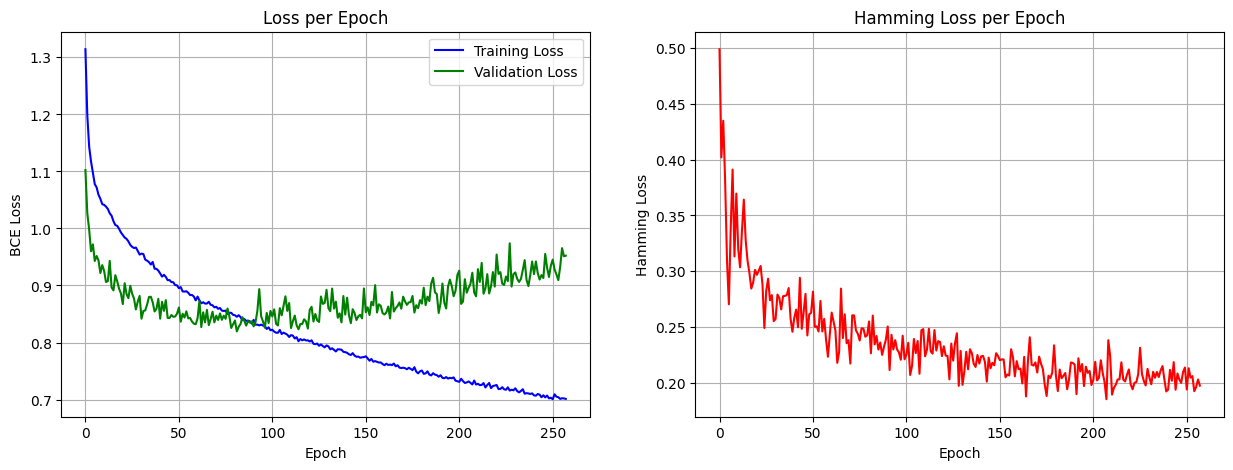

In [ ]:
# # Create a figure with two subplots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# # Training Loss
# ax1.plot(loss_history, label='Training Loss', color='blue')
# ax1.plot(val_loss_history, label='Validation Loss', color='green')
# ax1.set_title('Loss per Epoch')
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('BCE Loss')
# ax1.grid(True)
# ax1.legend()

# # Hamming Loss
# ax2.plot(hamming_history, label='Test Hamming Loss', color='red')
# ax2.set_title('Hamming Loss per Epoch')
# ax2.set_xlabel('Epoch')
# ax2.set_ylabel('Hamming Loss')
# ax2.grid(True)

# plt.show()

###Evaluating the model on the Test Set

#### Some metrics calculations

In [ ]:
# print("\n--- Final Test Set Evaluation ---")
# test_hamming, test_f1, test_acc = evaluate_model(test_loader, model)

# print(f"Hamming Loss: {test_hamming:.4f} (Lower is better)")
# print(f"Micro F1 Score: {test_f1:.4f} (Higher is better)")
# print(f"Subset Accuracy: {test_acc:.4f} (Strict exact match)")

# # Interpretation Check
# print(f"\nInterpretation: On average, the model predicts {test_hamming*100:.2f}% of the 138 smell labels incorrectly.")


--- Final Test Set Evaluation ---
Hamming Loss: 0.1815 (Lower is better)
Micro F1 Score: 0.1436 (Higher is better)
Subset Accuracy: 0.0421 (Strict exact match)

Interpretation: On average, the model predicts 18.15% of the 138 smell labels incorrectly.


####Top k Predictions method (Google)

In [ ]:
# def get_top_k_predictions(model, loader, smell_names, k=3):
#     model.eval()
#     results = []

#     with torch.no_grad():
#         for batch in loader:
#             logits = model(batch)

#             probs = torch.sigmoid(logits)
#             top_probs, top_indices = torch.topk(probs, k, dim=1)

#             top_probs = top_probs.cpu().numpy()
#             top_indices = top_indices.cpu().numpy()

#             for i in range(batch.num_graphs):
#                 current_names = [smell_names[idx] for idx in top_indices[i]]
#                 current_probs = top_probs[i]

#                 results.append(list(zip(current_names, current_probs)))

#     return results

In [ ]:
# num_positives

tensor([ 103.,  112.,  116.,   83.,   53.,   97.,   77.,  290.,   73.,   71.,
         257.,  119.,   40.,   27.,  131.,   57.,   29.,   40.,  176.,  129.,
          46.,  113.,  211.,   34.,   31.,   25.,  181.,   80.,   61.,   59.,
         327.,   80.,   29.,  113.,   84.,  103.,  110.,   69.,   63.,   49.,
          55.,  173.,   39.,  111.,  127.,  286.,  279.,  538.,  145.,   74.,
         886.,  459.,   49., 1664.,  113.,   34.,   52.,   84.,   45.,   61.,
        1246.,   32.,   68.,   49.,  633.,  148.,   51.,   77.,   49.,   47.,
          56.,   40.,  114.,   50.,   70.,   51.,   29.,  273.,   71.,  118.,
         110.,   72.,  182.,   31.,   89.,   60.,  188.,   52.,  323.,  123.,
         362.,  157.,   90.,   27.,   42.,   27.,   87.,  117.,  169.,   62.,
         193.,   54.,   29.,   52.,  137.,  190.,   54.,   32.,   82.,  260.,
         272.,   84.,   12.,  114.,  100.,   70.,   44.,   58.,   69.,  391.,
          45.,  359.,   36., 1291.,   50.,   42.,   86.,   36., 

In [ ]:
# # getting the name of all the columns in df and putting them on a list
# smell_list = df.columns[2:].tolist()

In [ ]:
# # getting the list of most frequent label to the least based on smell_list and num_positives
# most_frequent_smells = [smell for _, smell in sorted(zip(num_positives, smell_list), reverse=True)]

In [ ]:
# most_frequent_smells[0]

'fruity'

In [ ]:
# k = 10
# top_predictions = get_top_k_predictions(model, test_loader, smell_list, k)

In [ ]:
# which_molecule = 300

# smells_in_this_molecule = []

# for i in range(len(test_data[which_molecule].y)):
#   if (test_data[which_molecule].y[i] == 1):
#     smells_in_this_molecule.append(smell_list[i])

# print(f"Top {k} predictions for molecule {which_molecule}:")

# for i in range(k):
#   print(f"{i+1}. {top_predictions[which_molecule][i][0]} ({top_predictions[which_molecule][i][1]*100:.2f}%)")

# print(f"\nActual labels for molecule {which_molecule}:")
# print(test_data[which_molecule].y, "\n")

# print("Actual labels for molecule " + str(which_molecule) + " (names):", end = "")
# print(smells_in_this_molecule)

Top 10 predictions for molecule 300:
1. muguet (98.66%)
2. lily (96.22%)
3. citrus (93.98%)
4. lemon (91.55%)
5. clean (89.34%)
6. orange (89.31%)
7. solvent (84.21%)
8. soapy (83.38%)
9. odorless (83.11%)
10. ozone (83.08%)

Actual labels for molecule 300:
tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]) 

Actual labels for molecule 300 (names):['animal', 'woody']


#### AUROC and AUPRC

In [ ]:
# from sklearn.metrics import roc_curve, auc

# model.eval()
# y_true_list = []
# y_score_list = []

# print("Generating predictions for ROC Curve...")

# with torch.no_grad():
#     for batch in test_loader:
#         # Raw logits
#         out = model(batch)

#         # Sigmoid
#         probs = torch.sigmoid(out)

#         # Store
#         y_true_list.append(batch.y.view(batch.num_graphs, -1).cpu().numpy())
#         y_score_list.append(probs.cpu().numpy())

# # Stacking into big matrices
# y_true = np.vstack(y_true_list)
# y_score = np.vstack(y_score_list)

Generating predictions for ROC Curve...


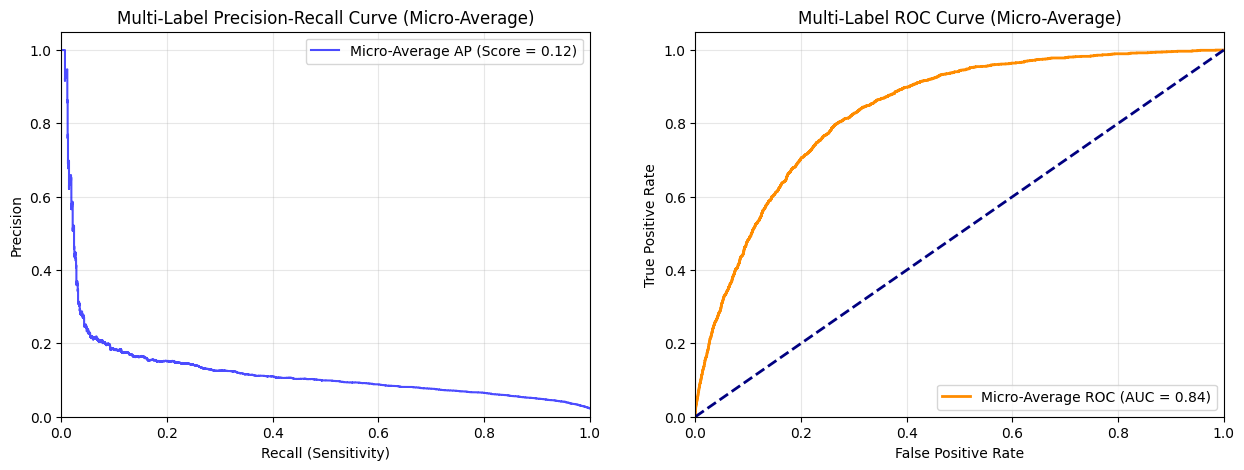

In [ ]:
# from sklearn.metrics import precision_recall_curve, average_precision_score

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# # Calculate Micro-Average ROC
# fpr, tpr, _ = roc_curve(y_true.ravel(), y_score.ravel())
# roc_auc = auc(fpr, tpr)

# # Calculate Micro-Average Precision-Recall
# precision, recall, _ = precision_recall_curve(y_true.ravel(), y_score.ravel())

# # Calculate the Average Precision (AP) Score (The area under this curve)
# average_precision = average_precision_score(y_true, y_score, average="micro")

# # Plot the PR Curve
# ax1.step(recall, precision, color='b', alpha=0.7, where='post', label=f'Micro-Average AP (Score = {average_precision:.2f})')

# ax1.set_xlabel('Recall (Sensitivity)')
# ax1.set_ylabel('Precision')
# ax1.set_ylim([0.0, 1.05])
# ax1.set_xlim([0.0, 1.0])
# ax1.set_title('Multi-Label Precision-Recall Curve (Micro-Average)')
# ax1.legend(loc="upper right")
# ax1.grid(alpha=0.3)

# # Plot the actual curve
# ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-Average ROC (AUC = {roc_auc:.2f})')

# # Plot the "Random Guess" diagonal line (dashed)
# ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# ax2.set_xlim([0.0, 1.0])
# ax2.set_ylim([0.0, 1.05])
# ax2.set_xlabel('False Positive Rate')
# ax2.set_ylabel('True Positive Rate')
# ax2.set_title('Multi-Label ROC Curve (Micro-Average)')
# ax2.legend(loc="lower right")
# ax2.grid(alpha=0.3)

# plt.show()

Best Class Index: 54 (AUC: 0.9987)
Worst Class Index: 127 (AUC: 0.1406)
Mean AUC across all classes: 0.7733


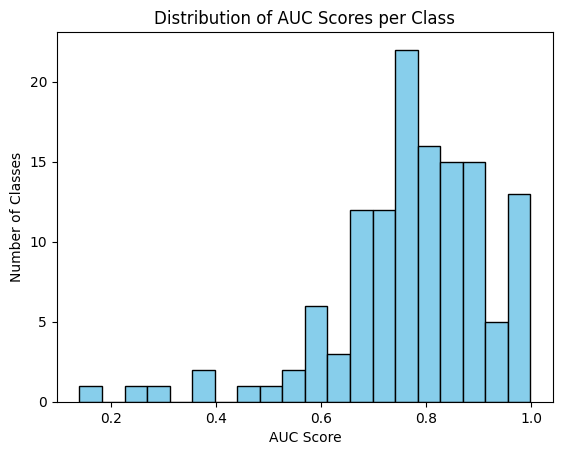

In [ ]:
# # Calculate AUC for each of the 138 classes individually
# class_aucs = []

# for i in range(y_true.shape[1]):
#     # Only calculate if the class actually exists in the test set
#     if np.sum(y_true[:, i]) > 0:
#         class_fpr, class_tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
#         class_auc = auc(class_fpr, class_tpr)
#         class_aucs.append(class_auc)
#     else:
#         # Handle rare classes that might not be in the test set
#         class_aucs.append(np.nan)

# # Convert to array for easy analysis
# class_aucs = np.array(class_aucs)

# print(f"Best Class Index: {np.nanargmax(class_aucs)} (AUC: {np.nanmax(class_aucs):.4f})")
# print(f"Worst Class Index: {np.nanargmin(class_aucs)} (AUC: {np.nanmin(class_aucs):.4f})")
# print(f"Mean AUC across all classes: {np.nanmean(class_aucs):.4f}")

# # Histogram of AUCs
# plt.hist(class_aucs, bins=20, color='skyblue', edgecolor='black')
# plt.title("Distribution of AUC Scores per Class")
# plt.xlabel("AUC Score")
# plt.ylabel("Number of Classes")
# plt.show()

# ________________________________________________________________________________________________________________________________________________________

# Training the model for the smells


## Using the model architecture from the following paper:

>"Machine Learning for Scent: Learning Generalizable Perceptual Representations of Small Molecules"

Available on: https://arxiv.org/pdf/1910.10685

Reference:

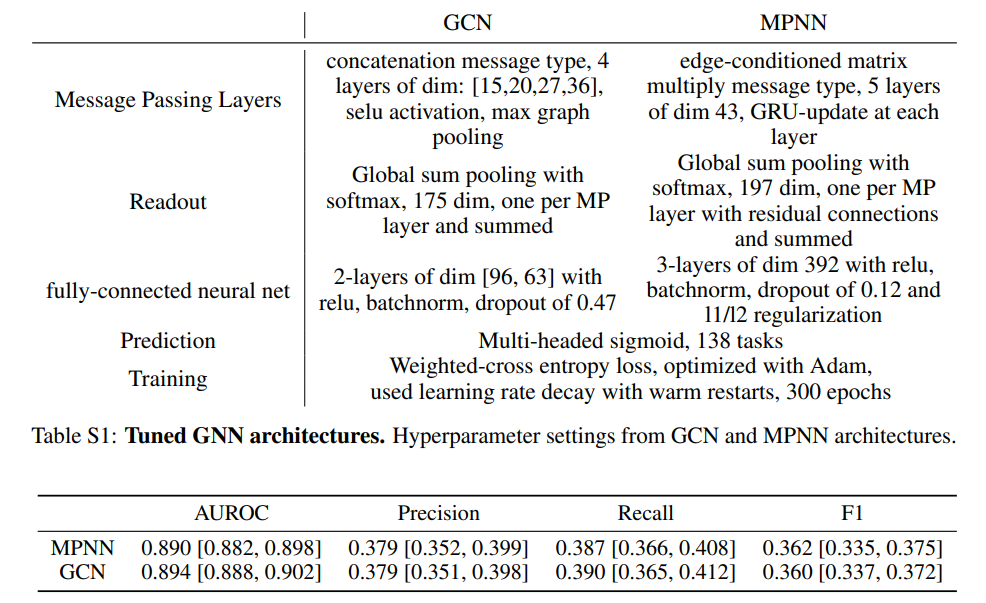

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
import numpy as np
import torch

def calculate_all_metrics(loader, model, device, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    y_true_all = []
    y_probs_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            # Forward pass
            out = model(batch)

            # Validation Loss
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            total_loss += loss.item()

            # Probabilities
            probs = torch.sigmoid(out)

            # Binary Predictions (for F1/Prec/Recall)
            preds = (probs > threshold).float()

            # Store
            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    # Concatenate
    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)
    y_pred = np.vstack(y_pred_all)

    avg_loss = total_loss / len(loader)

    # try:
    auroc = roc_auc_score(y_true, y_probs, average='micro') # re-run
    # except: auroc = 0.5

    aucpr = average_precision_score(y_true, y_probs, average='micro')

    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

    return avg_loss, auroc, aucpr, precision, recall, f1

###Model

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_add_pool
from torch.nn import Linear, BatchNorm1d, Dropout

class SmellGCN_Paper(torch.nn.Module):
    def __init__(self, num_node_features, num_classes=138):
        super(SmellGCN_Paper, self).__init__()

        # Layers
        self.conv1 = GCNConv(num_node_features, 15)
        self.conv2 = GCNConv(15, 20)
        self.conv3 = GCNConv(20, 27)
        self.conv4 = GCNConv(27, 36)

        # Readout: 175 dim
        self.mlp_input_dim = num_node_features + 15 + 20 + 27 + 36

        # MLP
        self.mlp1 = Linear(self.mlp_input_dim, 96)
        self.bn1 = BatchNorm1d(96)
        self.drop1 = Dropout(0.47)
        self.mlp2 = Linear(96, 63)
        self.bn2 = BatchNorm1d(63)
        self.drop2 = Dropout(0.47)

        self.out = Linear(63, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x0 = x

        x1 = F.selu(self.conv1(x0, edge_index))
        x2 = F.selu(self.conv2(x1, edge_index))
        x3 = F.selu(self.conv3(x2, edge_index))
        x4 = F.selu(self.conv4(x3, edge_index))

        # Readout
        g0 = global_add_pool(x0, batch)
        g1 = global_add_pool(x1, batch)
        g2 = global_add_pool(x2, batch)
        g3 = global_add_pool(x3, batch)
        g4 = global_add_pool(x4, batch)

        # Concatenate to get that ~175 dim vector
        x = torch.cat([g0, g1, g2, g3, g4], dim=1)

        # MLP
        x = self.mlp1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.mlp2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        return self.out(x)

###Training

In [ ]:
import torch
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SmellGCN_Paper(num_node_features=df_graph[0].x.shape[1], num_classes=138).to(device)

all_y_tensors = [data.y for data in train_data]
stacked_y_tensors = torch.stack(all_y_tensors)
num_positives = torch.sum(stacked_y_tensors, dim=0)
num_negatives = len(train_data) - num_positives
pos_weight = num_negatives / (num_positives + 1e-5) # Add epsilon to avoid div-by-zero
pos_weight = pos_weight.to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=1)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_auroc': [],
    'val_aucpr': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

epochs = 500
print(f"Starting Training ({epochs} epochs)...")

for epoch in range(epochs):
  model.train()
  train_loss = 0

  for batch in train_loader:
    batch = batch.to(device)
    optimizer.zero_grad()
    out = model(batch)
    loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
    loss.backward()
    optimizer.step()
    train_loss += loss.item()

  scheduler.step()
  avg_train_loss = train_loss / len(train_loader)

  val_loss, val_auroc, val_aucpr, val_prec, val_rec, val_f1 = calculate_all_metrics(val_loader, model, device, criterion)

  # Store
  history['train_loss'].append(avg_train_loss)
  history['val_loss'].append(val_loss)
  history['val_auroc'].append(val_auroc)
  history['val_aucpr'].append(val_aucpr)
  history['val_precision'].append(val_prec)
  history['val_recall'].append(val_rec)
  history['val_f1'].append(val_f1)

  if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch+1:03d} | Loss: {val_loss:.4f} | F1: {val_f1:.4f} | AUROC: {val_auroc:.4f}")

print("Training Complete.")


Starting Training (500 epochs)...
Epoch 010 | Loss: 1.1100 | F1: 0.1346 | AUROC: 0.7758
Epoch 020 | Loss: 1.0624 | F1: 0.1543 | AUROC: 0.7958
Epoch 030 | Loss: 1.0277 | F1: 0.1574 | AUROC: 0.8077
Epoch 040 | Loss: 1.0152 | F1: 0.1578 | AUROC: 0.8181
Epoch 050 | Loss: 1.0089 | F1: 0.1611 | AUROC: 0.8210
Epoch 060 | Loss: 1.0317 | F1: 0.1652 | AUROC: 0.8121
Epoch 070 | Loss: 1.0180 | F1: 0.1638 | AUROC: 0.8151
Epoch 080 | Loss: 0.9863 | F1: 0.1677 | AUROC: 0.8240
Epoch 090 | Loss: 0.9863 | F1: 0.1699 | AUROC: 0.8305
Epoch 100 | Loss: 0.9821 | F1: 0.1685 | AUROC: 0.8294
Epoch 110 | Loss: 1.0036 | F1: 0.1587 | AUROC: 0.8206
Epoch 120 | Loss: 0.9951 | F1: 0.1644 | AUROC: 0.8232
Epoch 130 | Loss: 0.9716 | F1: 0.1719 | AUROC: 0.8363
Epoch 140 | Loss: 0.9751 | F1: 0.1713 | AUROC: 0.8351
Epoch 150 | Loss: 0.9670 | F1: 0.1736 | AUROC: 0.8386
Epoch 160 | Loss: 0.9725 | F1: 0.1755 | AUROC: 0.8344
Epoch 170 | Loss: 0.9757 | F1: 0.1668 | AUROC: 0.8368
Epoch 180 | Loss: 0.9668 | F1: 0.1769 | AUROC: 0

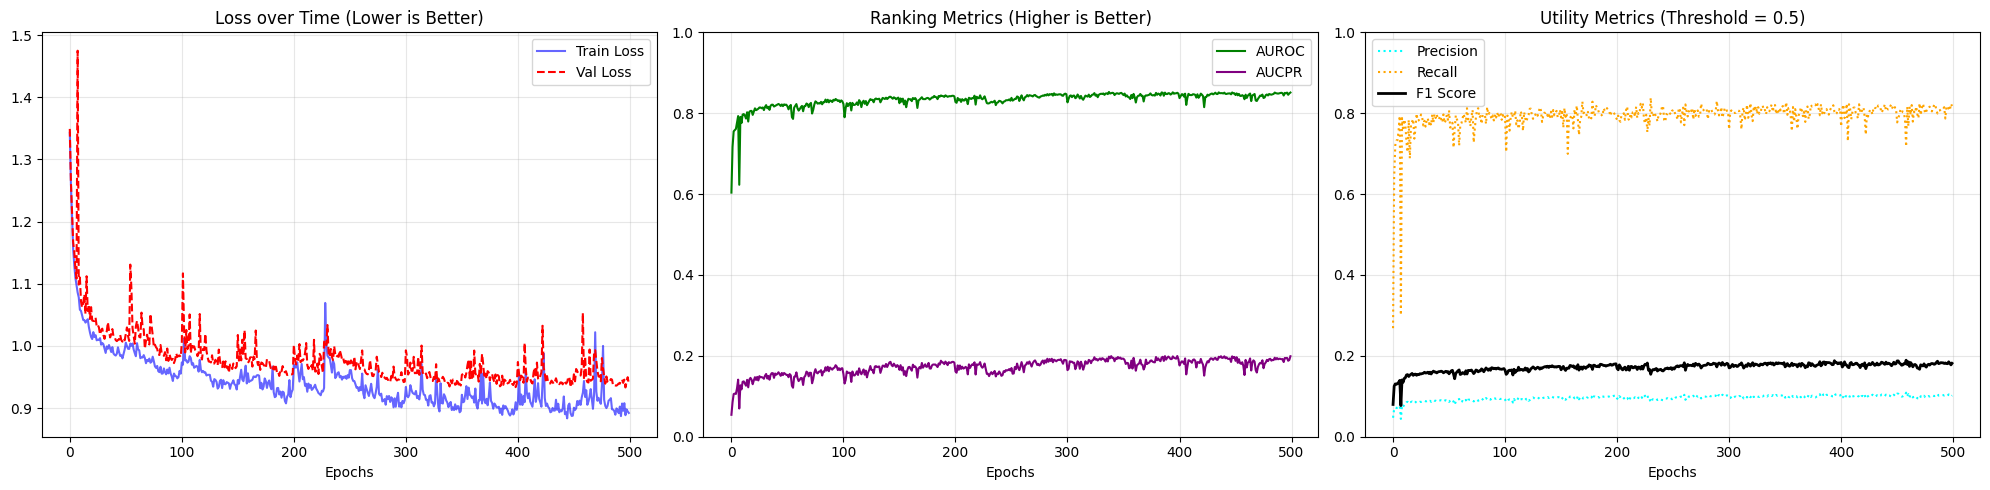

In [ ]:
import matplotlib.pyplot as plt

def plot_full_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    ax1.plot(history['train_loss'], label='Train Loss', color='blue', alpha=0.6)
    ax1.plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
    ax1.set_title('Loss over Time (Lower is Better)')
    ax1.set_xlabel('Epochs')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(history['val_auroc'], label='AUROC', color='green')
    ax2.plot(history['val_aucpr'], label='AUCPR', color='purple')
    ax2.set_title('Ranking Metrics (Higher is Better)')
    ax2.set_xlabel('Epochs')
    ax2.set_ylim([0, 1])
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3.plot(history['val_precision'], label='Precision', color='cyan', linestyle=':')
    ax3.plot(history['val_recall'], label='Recall', color='orange', linestyle=':')
    ax3.plot(history['val_f1'], label='F1 Score', color='black', linewidth=2)
    ax3.set_title('Utility Metrics (Threshold = 0.5)')
    ax3.set_xlabel('Epochs')
    ax3.set_ylim([0, 1])
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()

plot_full_history(history)

Values in the paper:

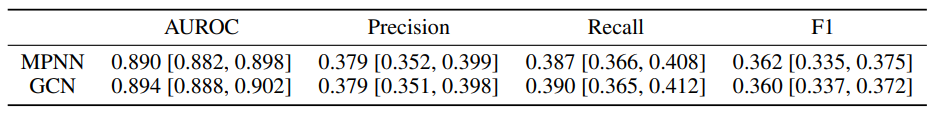

In [ ]:
# Last values found
history['train_loss'][-1],\
history['val_loss'][-1],\
history['val_auroc'][-1],\
history['val_aucpr'][-1],\
history['val_precision'][-1],\
history['val_recall'][-1],\
history['val_f1'][-1]

(0.8920407047271729,
 0.9389429613947868,
 np.float64(0.8510941015657997),
 np.float64(0.19906477232371267),
 0.10206530979646947,
 0.8177083333333334,
 0.18147868225670208)

### Optimizing the threshold before testing (using the validation set for it)
- Using a single value for the optimal threshold

In [ ]:
import numpy as np
from sklearn.metrics import f1_score
import torch

def find_optimal_threshold(val_loader, model, device):
    """
    Sweeps through thresholds on the validation set to find the one
    that maximizes the Micro-F1 score.
    """
    model.eval()
    y_true_all = []
    y_probs_all = []

    # 1. Gather all probabilities from the Validation Set
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            probs = torch.sigmoid(out) # Get probabilities between 0 and 1

            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())

    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)

    best_threshold = 0.5
    best_f1 = 0.0

    print("Sweeping thresholds...")

    # 2. Test every threshold from 0.01 to 0.99 in increments of 0.01
    thresholds_to_test = np.arange(0.01, 1.0, 0.01)

    for thresh in thresholds_to_test:
        # Convert probabilities to binary predictions using the current threshold
        y_pred = (y_probs >= thresh).astype(int)

        # Calculate Micro-F1
        current_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

        # Keep track of the best one
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = thresh

    print(f"Optimal Threshold Found: {best_threshold:.2f} (Val F1: {best_f1:.4f})")
    return best_threshold

In [ ]:
optimal_threshold = find_optimal_threshold(val_loader, model, device)

Sweeping thresholds...
Optimal Threshold Found: 0.75 (Val F1: 0.2641)


### Testing

In [ ]:
def calculate_all_metrics(loader, model, device, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    y_true_all = []
    y_probs_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            # Forward pass
            out = model(batch)

            # Validation Loss
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            total_loss += loss.item()

            # Probabilities
            probs = torch.sigmoid(out)

            # Binary Predictions (for F1/Prec/Recall)
            preds = (probs > threshold).float()

            # Store
            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    # Concatenate
    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)
    y_pred = np.vstack(y_pred_all)

    avg_loss = total_loss / len(loader)

    # try:
    auroc = roc_auc_score(y_true, y_probs, average='micro') # re-run
    # except: auroc = 0.5

    aucpr = average_precision_score(y_true, y_probs, average='micro')

    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

    return avg_loss, auroc, aucpr, precision, recall, f1

In [ ]:
_, test_auroc, _, test_prec, test_rec, test_f1 = calculate_all_metrics(test_loader, model, device, criterion, optimal_threshold)

print(f"{'AUROC':<10} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10}")
print("-" * 46)
print(f"{test_auroc:<10.4f} | {test_prec:<10.4f} | {test_rec:<10.4f} | {test_f1:<10.4f}")
print("-" * 46)

AUROC      | Precision  | Recall     | F1 Score  
----------------------------------------------
0.8561     | 0.1974     | 0.3825     | 0.2604    
----------------------------------------------


In [ ]:
# print("\nInterpretation:")
# print(f"- AUROC ({test_auroc:.2f}): Global ranking capability.")
# print(f"- Precision ({test_prec:.2f}): Reliability (How many predicted smells are real?).")
# print(f"- Recall ({test_rec:.2f}): Sensitivity (How many real smells did we find?).")

### Optimizing the threshold before testing (using the validation set for it)
  - Using one threshold adjusted for each label

In [ ]:
import numpy as np
from sklearn.metrics import f1_score
import torch

def find_per_label_thresholds(val_loader, model, device, num_classes=138):
    model.eval()
    y_true_all = []
    y_probs_all = []

    # 1. Gather all probabilities from the Validation Set
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            probs = torch.sigmoid(out)

            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())

    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)

    # Initialize an array to hold the 138 best thresholds (default to 0.5)
    best_thresholds = np.full(num_classes, 0.5)

    print(f"Sweeping thresholds for all {num_classes} labels individually...")

    # 2. Loop through each smell label (column)
    for class_idx in range(num_classes):
        # Isolate the true labels and probabilities for THIS specific smell
        y_true_class = y_true[:, class_idx]
        y_probs_class = y_probs[:, class_idx]

        # Safety check: If a smell doesn't exist in the validation set at all, skip it
        if np.sum(y_true_class) == 0:
            continue

        best_f1 = 0.0
        best_thresh = 0.5

        # Test thresholds for this specific smell
        for thresh in np.arange(0.01, 1.0, 0.01):
            y_pred_class = (y_probs_class >= thresh).astype(int)

            # Calculate the F1 score for this class only
            current_f1 = f1_score(y_true_class, y_pred_class, zero_division=0)

            if current_f1 > best_f1:
                best_f1 = current_f1
                best_thresh = thresh

        # Save the winning threshold for this smell
        best_thresholds[class_idx] = best_thresh

    print("Done! Found 138 optimal thresholds.")
    return best_thresholds

In [ ]:
optimal_thresholds = find_per_label_thresholds(val_loader, model, device)

Sweeping thresholds for all 138 labels individually...
Done! Found 138 optimal thresholds.


In [ ]:
thresholds_tensor = torch.tensor(optimal_thresholds, dtype=torch.float32).to(device)

In [ ]:
def calculate_all_metrics_thresh(loader, model, device, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    y_true_all = []
    y_probs_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            # Forward pass
            out = model(batch)

            # Validation Loss
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            total_loss += loss.item()

            # Probabilities
            probs = torch.sigmoid(out)

            # Binary Predictions (for F1/Prec/Recall)
            preds = (probs > threshold).float()

            # Store
            y_true_all.append(batch.y.view(batch.num_graphs, -1).float())
            y_probs_all.append(probs.cpu().numpy())
            y_pred_all.append(preds.cpu().numpy())

    # Concatenate
    y_true = np.vstack(y_true_all)
    y_probs = np.vstack(y_probs_all)
    y_pred = np.vstack(y_pred_all)

    avg_loss = total_loss / len(loader)

    # try:
    auroc = roc_auc_score(y_true, y_probs, average='micro') # re-run
    # except: auroc = 0.5

    aucpr = average_precision_score(y_true, y_probs, average='micro')

    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

    return avg_loss, auroc, aucpr, precision, recall, f1

In [ ]:
_, test_auroc, _, test_prec, test_rec, test_f1 = calculate_all_metrics_thresh(test_loader, model, device, criterion, thresholds_tensor)

print(f"{'AUROC':<10} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10}")
print("-" * 46)
print(f"{test_auroc:<10.4f} | {test_prec:<10.4f} | {test_rec:<10.4f} | {test_f1:<10.4f}")
print("-" * 46)

AUROC      | Precision  | Recall     | F1 Score  
----------------------------------------------
0.8561     | 0.2616     | 0.5158     | 0.3471    
----------------------------------------------


Analysis of the found thresholds

In [ ]:
df.columns

Index(['nonStereoSMILES', 'descriptors', 'alcoholic', 'aldehydic',
       'alliaceous', 'almond', 'amber', 'animal', 'anisic', 'apple',
       ...
       'tropical', 'vanilla', 'vegetable', 'vetiver', 'violet', 'warm', 'waxy',
       'weedy', 'winey', 'woody'],
      dtype='object', length=140)

In [ ]:
smell_list = []

for i in df.columns:
  smell_list.append(i)

smell_list = smell_list[2:]

In [ ]:
import numpy as np

def analyze_thresholds(thresholds, smell_names):
    """
    Prints the smells the model is most and least confident about
    based on their optimal F1 thresholds.
    """
    # np.argsort returns the indices that would sort the array from lowest to highest
    sorted_indices = np.argsort(thresholds)

    print("\n" + "="*40)
    print("MODEL CONFIDENCE ANALYSIS")
    print("="*40)

    print("\n🟢 Top 5 MOST Confident Smells (Highest Thresholds):")
    print("   (The model easily detects these, so it set a strict bar to avoid false alarms.)")

    # Take the last 5 indices and reverse them ([::-1]) so the absolute highest is first
    top_5_indices = sorted_indices[-5:][::-1]
    for rank, idx in enumerate(top_5_indices, 1):
        print(f"   {rank}. {smell_names[idx].capitalize():<15} | Threshold: {thresholds[idx]:.2f}")


    print("\n🔴 Top 5 LEAST Confident Smells (Lowest Thresholds):")
    print("   (The model struggles here; it had to lower the bar significantly to catch them.)")

    # Take the first 5 indices (the lowest values)
    bottom_5_indices = sorted_indices[:5]
    for rank, idx in enumerate(bottom_5_indices, 1):
        print(f"   {rank}. {smell_names[idx].capitalize():<15} | Threshold: {thresholds[idx]:.2f}")

# --- Usage Example ---
# Assuming 'optimal_thresholds' is the array you got from the previous function
# and 'smell_list' is your list of 138 strings:

analyze_thresholds(optimal_thresholds, smell_list)


MODEL CONFIDENCE ANALYSIS

🟢 Top 5 MOST Confident Smells (Highest Thresholds):
   (The model easily detects these, so it set a strict bar to avoid false alarms.)
   1. Alcoholic       | Threshold: 0.94
   2. Malty           | Threshold: 0.94
   3. Bergamot        | Threshold: 0.93
   4. Cucumber        | Threshold: 0.93
   5. Tomato          | Threshold: 0.92

🔴 Top 5 LEAST Confident Smells (Lowest Thresholds):
   (The model struggles here; it had to lower the bar significantly to catch them.)
   1. Sulfurous       | Threshold: 0.34
   2. Fruity          | Threshold: 0.51
   3. Green           | Threshold: 0.51
   4. Sweet           | Threshold: 0.52
   5. Spicy           | Threshold: 0.53


# Training the model for the sensors predictions


## Using the model architecture from the following paper with some adjustments:

>"Machine Learning for Scent: Learning Generalizable Perceptual Representations of Small Molecules"

Available on: https://arxiv.org/pdf/1910.10685

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import torch

def calculate_all_metrics(loader, model, device, criterion):
    model.eval()
    total_loss = 0
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            out = model(batch)

            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            total_loss += loss.item()

            y_true_all.append(batch.y.view(batch.num_graphs, -1).float().cpu().numpy())
            y_pred_all.append(out.cpu().numpy())

    y_true = np.vstack(y_true_all)
    y_pred = np.vstack(y_pred_all)

    avg_loss = total_loss / len(loader)

    # Global R² across all sensors
    r2 = r2_score(y_true, y_pred, multioutput='uniform_average')

    # Per-sensor R² (useful for debugging which sensor is hard to predict)
    r2_per_sensor = r2_score(y_true, y_pred, multioutput='raw_values')

    # MAE globally and per sensor
    mae = mean_absolute_error(y_true, y_pred, multioutput='uniform_average')
    mae_per_sensor = mean_absolute_error(y_true, y_pred, multioutput='raw_values')

    return avg_loss, r2, mae, r2_per_sensor, mae_per_sensor

###Model

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_add_pool
from torch.nn import Linear, BatchNorm1d, Dropout

class SensorGCN(torch.nn.Module):
    def __init__(self, num_node_features, num_sensors=8):
        super(SensorGCN, self).__init__()
        # Graph conv layers (unchanged)
        self.conv1 = GCNConv(num_node_features, 15)
        self.conv2 = GCNConv(15, 20)
        self.conv3 = GCNConv(20, 27)
        self.conv4 = GCNConv(27, 36)

        # Readout: same concatenated dim
        self.mlp_input_dim = num_node_features + 15 + 20 + 27 + 36

        # MLP (you may want to tune these dims for the smaller output task)
        self.mlp1 = Linear(self.mlp_input_dim, 96)
        self.bn1 = BatchNorm1d(96)
        self.drop1 = Dropout(0.47)
        self.mlp2 = Linear(96, 63)
        self.bn2 = BatchNorm1d(63)
        self.drop2 = Dropout(0.47)

        # Output: 8 continuous values instead of 138 binary classes
        self.out = Linear(63, num_sensors)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x0 = x
        x1 = F.selu(self.conv1(x0, edge_index))
        x2 = F.selu(self.conv2(x1, edge_index))
        x3 = F.selu(self.conv3(x2, edge_index))
        x4 = F.selu(self.conv4(x3, edge_index))

        # Readout (unchanged)
        g0 = global_add_pool(x0, batch)
        g1 = global_add_pool(x1, batch)
        g2 = global_add_pool(x2, batch)
        g3 = global_add_pool(x3, batch)
        g4 = global_add_pool(x4, batch)

        x = torch.cat([g0, g1, g2, g3, g4], dim=1)

        # MLP (unchanged)
        x = self.mlp1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)
        x = self.mlp2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        # No sigmoid/softmax — raw linear output for regression
        return self.out(x)

###Training

In [ ]:
import torch
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SensorGCN(num_node_features=df_graph[0].x.shape[1]).to(device)

# No pos_weight needed — regression has no class imbalance concept
criterion = torch.nn.HuberLoss()  # Robust to outliers; swap for MSELoss() if targets are clean
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=1)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_r2': [],
    'val_mae': [],
    'val_r2_per_sensor': [],
    'val_mae_per_sensor': []
}

epochs = 500
print(f"Starting Training ({epochs} epochs)...")

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    avg_train_loss = train_loss / len(train_loader)

    val_loss, val_r2, val_mae, val_r2_per_sensor, val_mae_per_sensor = calculate_all_metrics(
        val_loader, model, device, criterion
    )

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_r2'].append(val_r2)
    history['val_mae'].append(val_mae)
    history['val_r2_per_sensor'].append(val_r2_per_sensor)
    history['val_mae_per_sensor'].append(val_mae_per_sensor)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Loss: {val_loss:.4f} | R²: {val_r2:.4f} | MAE: {val_mae:.4f}")

print("Training Complete.")

Starting Training (500 epochs)...
Epoch 010 | Loss: 0.2699 | R²: nan | MAE: 0.6770


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

Epoch 020 | Loss: 0.0990 | R²: nan | MAE: 0.3517
Epoch 030 | Loss: 0.0294 | R²: nan | MAE: 0.2054


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

Epoch 040 | Loss: 0.0442 | R²: nan | MAE: 0.2507
Epoch 050 | Loss: 0.0270 | R²: nan | MAE: 0.2012


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

Epoch 470 | Loss: 0.0158 | R²: nan | MAE: 0.1589
Epoch 480 | Loss: 0.0119 | R²: nan | MAE: 0.1350


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

Epoch 490 | Loss: 0.0093 | R²: nan | MAE: 0.1096
Epoch 500 | Loss: 0.0093 | R²: nan | MAE: 0.1108
Training Complete.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

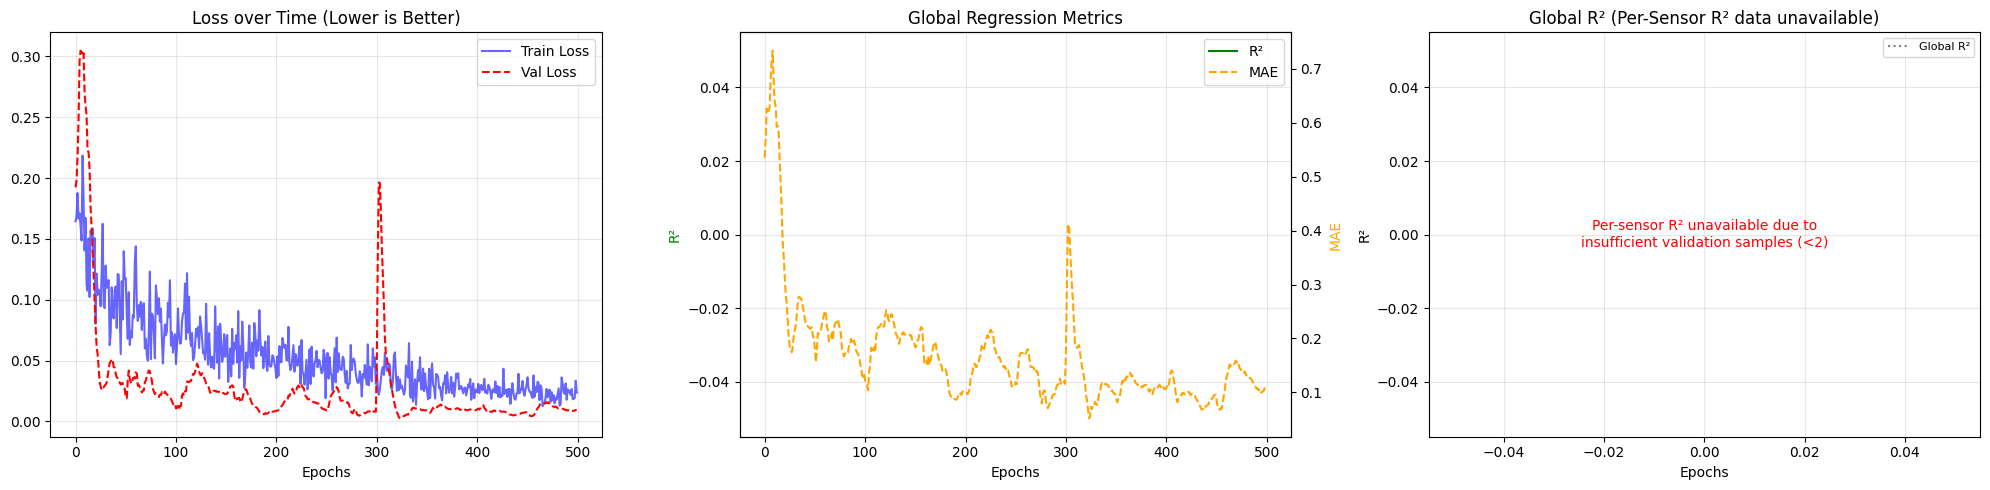

In [ ]:
# import matplotlib.pyplot as plt

# SENSOR_IDS = [1, 105, 106, 24, 25, 34, 36, 55]  # adjust if needed

# def plot_full_history(history):
#     fig, axes = plt.subplots(1, 3, figsize=(20, 5))

#     # --- Plot 1: Loss ---
#     axes[0].plot(history['train_loss'], label='Train Loss', color='blue', alpha=0.6)
#     axes[0].plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
#     axes[0].set_title('Loss over Time (Lower is Better)')
#     axes[0].set_xlabel('Epochs')
#     axes[0].grid(True, alpha=0.3)
#     axes[0].legend()

#     # --- Plot 2: Global R² and MAE ---
#     ax2b = axes[1].twinx()
#     axes[1].plot(history['val_r2'],  label='R²',  color='green')
#     ax2b.plot(   history['val_mae'], label='MAE', color='orange', linestyle='--')
#     axes[1].set_title('Global Regression Metrics')
#     axes[1].set_xlabel('Epochs')
#     axes[1].set_ylabel('R²',  color='green')
#     ax2b.set_ylabel( 'MAE', color='orange')
#     axes[1].grid(True, alpha=0.3)
#     # Combine legends from both y-axes
#     lines1, labels1 = axes[1].get_legend_handles_labels()
#     lines2, labels2 = ax2b.get_legend_handles_labels()
#     axes[1].legend(lines1 + lines2, labels1 + labels2)

#     # --- Plot 3: Per-sensor R² across epochs ---
#     r2_per_sensor = np.array(history['val_r2_per_sensor'])  # shape: (epochs, 8)
#     colors = plt.cm.tab10.colors
#     for i, sensor_id in enumerate(SENSOR_IDS):
#         axes[2].plot(r2_per_sensor[:, i], label=f'Sensor {sensor_id}',
#                      color=colors[i % len(colors)])
#     axes[2].set_title('Per-Sensor R² (Higher is Better)')
#     axes[2].set_xlabel('Epochs')
#     axes[2].set_ylabel('R²')
#     axes[2].grid(True, alpha=0.3)
#     axes[2].legend(fontsize=8)

#     plt.tight_layout()
#     plt.show()

# plot_full_history(history)

Plotting when we have very few values in our dataset:

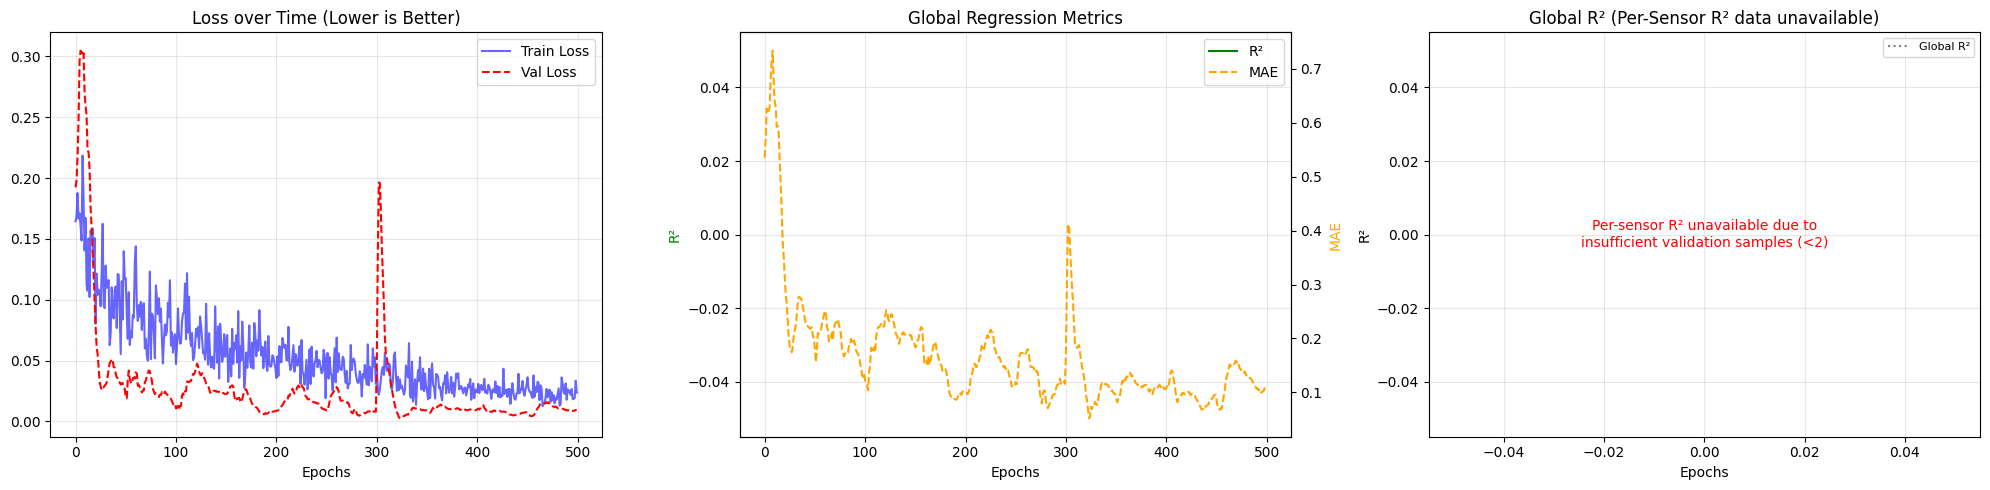

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

SENSOR_IDS = [1, 105, 106, 24, 25, 34, 36, 55]  # adjust if needed

def plot_full_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # --- Plot 1: Loss ---
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue', alpha=0.6)
    axes[0].plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
    axes[0].set_title('Loss over Time (Lower is Better)')
    axes[0].set_xlabel('Epochs')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # --- Plot 2: Global R² and MAE ---
    ax2b = axes[1].twinx()
    axes[1].plot(history['val_r2'],  label='R²',  color='green')
    ax2b.plot(   history['val_mae'], label='MAE', color='orange', linestyle='--')
    axes[1].set_title('Global Regression Metrics')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('R²',  color='green')
    ax2b.set_ylabel( 'MAE', color='orange')
    axes[1].grid(True, alpha=0.3)
    # Combine legends from both y-axes
    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    axes[1].legend(lines1 + lines2, labels1 + labels2)

    # --- Plot 3: Per-sensor R² across epochs ---
    r2_per_sensor = np.array(history['val_r2_per_sensor'])  # shape: (epochs,) or (epochs, 8)

    if r2_per_sensor.ndim == 2 and r2_per_sensor.shape[1] == len(SENSOR_IDS):
        # Data is in the expected 2D format for per-sensor plotting
        colors = plt.cm.tab10.colors
        for i, sensor_id in enumerate(SENSOR_IDS):
            axes[2].plot(r2_per_sensor[:, i], label=f'Sensor {sensor_id}',
                         color=colors[i % len(colors)])
        axes[2].set_title('Per-Sensor R² (Higher is Better)')
        axes[2].legend(fontsize=8)
    else:
        # Per-sensor R² data is not in the expected 2D format (likely 1D array of NaNs)
        # Plot global R² as a fallback, which should be a 1D array already.
        axes[2].plot(history['val_r2'], label='Global R²', color='gray', linestyle=':')
        axes[2].set_title('Global R² (Per-Sensor R² data unavailable)')
        axes[2].text(0.5, 0.5, 'Per-sensor R² unavailable due to\ninsufficient validation samples (<2)',
                     horizontalalignment='center', verticalalignment='center',
                     transform=axes[2].transAxes, fontsize=10, color='red')
        axes[2].legend(fontsize=8)

    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('R²')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_full_history(history)

### Testing

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr
import numpy as np
import torch

SENSOR_IDS = [1, 105, 106, 24, 25, 34, 36, 55]

def calculate_all_metrics(loader, model, device, criterion, tolerance=None):
    """
    Computes regression metrics for multi-output sensor prediction.

    Metrics per sensor and globally:
      - R²    : how much variance is explained (1.0 = perfect)
      - MAE   : mean absolute error (same units as your targets)
      - RMSE  : penalises large errors more than MAE
      - PCC   : Pearson correlation between predictions and ground truth
      - Acc@δ : % of predictions within `tolerance` of the true value
                (only computed if tolerance is provided)
    """
    model.eval()
    total_loss = 0
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            out  = model(batch)
            loss = criterion(out, batch.y.view(batch.num_graphs, -1).float())
            total_loss += loss.item()

            y_true_all.append(batch.y.view(batch.num_graphs, -1).float().cpu().numpy())
            y_pred_all.append(out.cpu().numpy())

    y_true = np.vstack(y_true_all)  # (n_samples, 8)
    y_pred = np.vstack(y_pred_all)  # (n_samples, 8)

    avg_loss = total_loss / len(loader)

    # --- Global metrics ---
    r2_global   = r2_score(y_true, y_pred, multioutput='uniform_average')
    mae_global  = mean_absolute_error(y_true, y_pred, multioutput='uniform_average')
    rmse_global = np.sqrt(np.mean((y_true - y_pred) ** 2))

    # --- Per-sensor metrics ---
    r2_per_sensor   = r2_score(y_true, y_pred, multioutput='raw_values')           # (8,)
    mae_per_sensor  = mean_absolute_error(y_true, y_pred, multioutput='raw_values') # (8,)
    rmse_per_sensor = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))             # (8,)
    pcc_per_sensor  = np.array([
        pearsonr(y_true[:, i], y_pred[:, i])[0]
        for i in range(y_true.shape[1])
    ])

    # --- Acc@δ (optional, requires tolerance from find_optimal_tolerance) ---
    acc_per_sensor = None
    acc_global     = None
    if tolerance is not None:
        within_tol     = np.abs(y_pred - y_true) <= tolerance  # (n_samples, 8)
        acc_per_sensor = within_tol.mean(axis=0)               # (8,)
        acc_global     = acc_per_sensor.mean()                 # scalar

    # --- Pretty print ---
    print(f"\n{'='*65}")
    print(f"  METRICS  (loss = {avg_loss:.4f})")
    print(f"{'='*65}")
    tol_header = f"{'Acc@δ':>8}" if tolerance is not None else ""
    print(f"  {'Sensor':<10} {'R²':>7} {'MAE':>7} {'RMSE':>7} {'PCC':>7} {tol_header}")
    print(f"  {'-'*55}")

    for i, sid in enumerate(SENSOR_IDS):
        tol_col = f"{acc_per_sensor[i]:>8.4f}" if tolerance is not None else ""
        print(f"  {sid:<10} {r2_per_sensor[i]:>7.4f} {mae_per_sensor[i]:>7.4f} "
              f"{rmse_per_sensor[i]:>7.4f} {pcc_per_sensor[i]:>7.4f} {tol_col}")

    print(f"  {'-'*55}")
    tol_global_col = f"{acc_global:>8.4f}" if tolerance is not None else ""
    print(f"  {'Global':<10} {r2_global:>7.4f} {mae_global:>7.4f} "
          f"{rmse_global:>7.4f} {'—':>7} {tol_global_col}")
    print(f"{'='*65}\n")

    return {
        'loss'          : avg_loss,
        'r2'            : r2_global,
        'mae'           : mae_global,
        'rmse'          : rmse_global,
        'r2_per_sensor' : r2_per_sensor,
        'mae_per_sensor': mae_per_sensor,
        'rmse_per_sensor': rmse_per_sensor,
        'pcc_per_sensor': pcc_per_sensor,
        'acc_per_sensor': acc_per_sensor,
        'acc_global'    : acc_global,
        'y_true'        : y_true,
        'y_pred'        : y_pred,
    }

In [ ]:
test_metrics = calculate_all_metrics(test_loader, model, device, criterion)

print(f"Test Loss: {test_metrics['loss']:.4f}")
print(f"Test R²: {test_metrics['r2']:.4f}")
print(f"Test MAE: {test_metrics['mae']:.4f}")
print(f"Test RMSE: {test_metrics['rmse']:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


ValueError: `x` and `y` must have length at least 2.